# LAB 3A : Implement Simple Linear regression

## Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## import dataset

In [4]:
dataset = pd.read_csv(".\Salary.csv")

## EDA Steps

In [5]:
dataset.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [6]:
dataset.shape

(30, 2)

In [7]:
dataset.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


In [9]:
dataset.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


## Preprocessing Steps

In [10]:
# Step 1 : Seprate i/p Independent Var and 
# o/p Dependent Var
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [11]:
print(X.head())

   YearsExperience
0              1.1
1              1.3
2              1.5
3              2.0
4              2.2


In [12]:
print(y.head())

0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
Name: Salary, dtype: float64


In [13]:
# Step 4 : Split data into training and testin
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split (X,y,
                                        test_size = 0.3,
                                        random_state = 0)

In [14]:
print(X_train.shape)
print(X_test.shape)

(21, 1)
(9, 1)


## Create the Regression model on training data

In [15]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

regressor.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
print("Intercept B0 = ",regressor.intercept_)
print("Coefficient B1= ",regressor.coef_)

Intercept B0 =  26777.391341197625
Coefficient B1=  [9360.26128619]


From Above values our model regression line equation

**y = 26777.391341197632 + 9360.26128619 * X**

By using this equation lets find salary for Experince =6

In [17]:
ynew = 26777.391341197632 + 9360.26128619 * 6

print("Salary for 6 yr experience = ",ynew)

Salary for 6 yr experience =  82938.95905833764


In [18]:
a = [[6.0]]
ynew = regressor.predict(a)
print(ynew)

[82938.95905836]


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [19]:
ypred = regressor.predict(X_test)

In [20]:
print(ypred)
print(y_test)

[ 40817.78327049 123188.08258899  65154.46261459  63282.41035735
 115699.87356004 108211.66453108 116635.89968866  64218.43648597
  76386.77615802]
2      37731.0
28    122391.0
13     57081.0
10     63218.0
26    116969.0
24    109431.0
27    112635.0
11     55794.0
17     83088.0
Name: Salary, dtype: float64


#### Accuracy of model

In [21]:
# 1. Training Accuracy

print("Training accuracy =",
      regressor.score(X_train,y_train))

Training accuracy = 0.9423777652193379


In [22]:
# 2. Testing Accuracy

print("Testing accuracy =",
      regressor.score(X_test,y_test))

Testing accuracy = 0.9740993407213511


### Visualizing the Model

#### 1. Visualize the training data

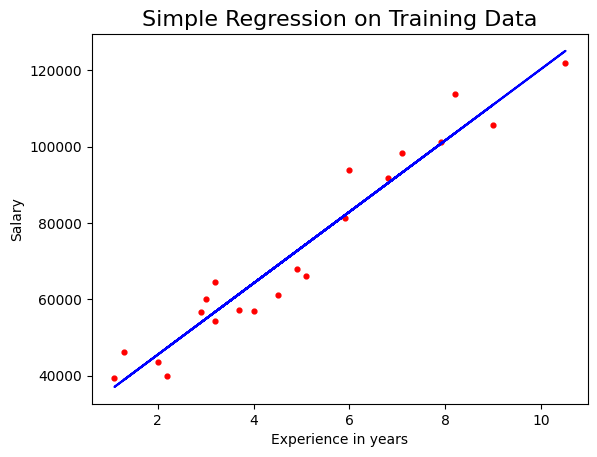

In [23]:
plt.scatter(X_train,y_train,color = 'red', s= 12)
plt.plot(X_train, regressor.predict(X_train),
        color = 'blue')
plt.title("Simple Regression on Training Data", size= 16)
plt.xlabel("Experience in years")
plt.ylabel("Salary")
plt.show()

#### 2. Visualize the testing data

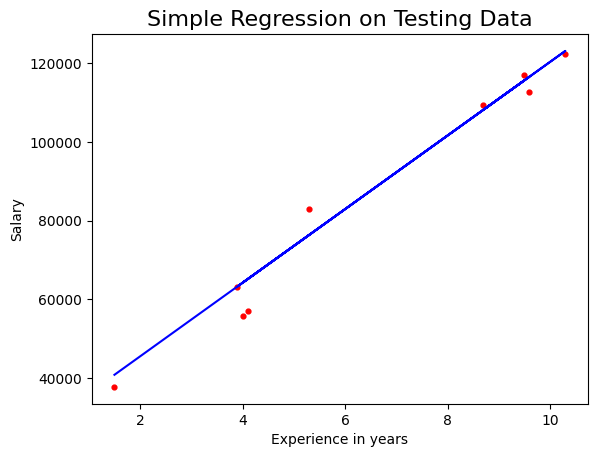

In [24]:
plt.scatter(X_test,y_test,color = 'red', s= 12)
plt.plot(X_test, regressor.predict(X_test),
        color = 'blue')
plt.title("Simple Regression on Testing Data", size= 16)
plt.xlabel("Experience in years")
plt.ylabel("Salary")
plt.show()

#### Find R^2 Score of model

In [25]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.9740993407213511

In [26]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, ypred)

23370078.800832972

In [27]:
from sklearn.metrics import median_absolute_error
median_absolute_error(y_train, regressor.predict(X_train))

5037.753526827422

median_absolute_error(y_test, regressor.predict(X_test))